In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import importlib.metadata

try:
    importlib.metadata.version('venn')
    importlib.metadata.version('pyyaml')
    importlib.metadata.version('scikit-learn')
except importlib.metadata.PackageNotFoundError:
    print("Installing missing packages...")
    ! python -m pip install venn pyyaml scikit-learn

# Get max curated data

In [3]:
import requests
from pathlib import Path
from yaml import safe_load
import numpy as np
import re

DATA_DIR = Path("data/max-curated")
DATA_DIR.mkdir(exist_ok=True, parents=True)

activities = ["Ki", "IC50"]
data_url = "https://raw.githubusercontent.com/rinikerlab/overlapping_assays/refs/heads/main/datasets/{dataset}_datasets.yaml"


command_str = (
    "capricho get -tids {targets} -chiral -duchi -reqdoc "
    "-cure --max-assay-size 100 --min-assay-size 20 --min-assay-overlap 5 -smr -calc -c 9 -idcols assay_type,assay_cell_type "
    "-biotype {activity} -o {output}"
)

## Ki

In [4]:
result = requests.get(data_url.format(dataset=activities[0]))
result.raise_for_status()

datasets = safe_load(result.content)

ki_targets = []
keys = datasets["sources"].keys()
for key in keys:
    ki_targets.append(datasets["sources"][key]["description"])

ki_targets = np.unique(ki_targets).tolist()
ki_targets = [re.compile("(CHEMBL\d+)").search(t).group(1) for t in ki_targets]

ki_output = DATA_DIR / "curated-Ki-NoAssayOverlap.csv"
command = command_str.format(targets=",".join(ki_targets), activity=activities[0], output=str(ki_output))

if not ki_output.exists():
    ! {command}
else:
    print(f"Data already exists: {ki_output}")
    print("Delete this file to re-fetch with updated parameters.")

Data already exists: data/max-curated/curated-Ki-NoAssayOverlap.csv
Delete this file to re-fetch with updated parameters.


## IC50

In [5]:
result = requests.get(data_url.format(dataset=activities[1]))
result.raise_for_status()

datasets = safe_load(result.content)

ic50_targets = []
keys = datasets["sources"].keys()
for key in keys:
    ic50_targets.append(datasets["sources"][key]["description"])

ic50_targets = np.unique(ic50_targets).tolist()
ic50_targets = [re.compile("(CHEMBL\d+)").search(t).group(1) for t in ic50_targets]

ic50_output = DATA_DIR / "curated-IC50-NoAssayOverlap.csv"
command = command_str.format(targets=",".join(ic50_targets), activity=activities[1], output=str(ic50_output))

if not ic50_output.exists():
    ! {command}
else:
    print(f"Data already exists: {ic50_output}")
    print("Delete this file to re-fetch with updated parameters.")

Data already exists: data/max-curated/curated-IC50-NoAssayOverlap.csv
Delete this file to re-fetch with updated parameters.


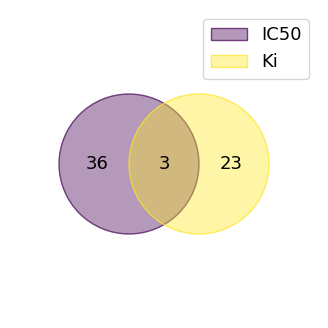

In [6]:
from venn import venn

venn_dict = {"IC50": set(ic50_targets), "Ki": set(ki_targets)}
venn(venn_dict, figsize=(4, 4))

plt.show()

# IC50 overlap

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from Capricho.analysis import (
    DroppingComment,
    ProcessingComment,
    explode_assay_comparability,
    get_all_comments,
    plot_multi_panel_comparability,
    plot_subset,
)

In [8]:
df = pd.read_csv(ic50_output, engine="pyarrow")
subset = df.query('processed_smiles.str.contains("|", regex=False)').assign(repeat=lambda x: range(len(x)))
subset.shape

(3113, 39)

In [9]:
df.data_processing_comment.apply(
    lambda x: x.split("|") if isinstance(x, str) else []
).explode().value_counts()

data_processing_comment
                                                                                    5872
Salt/solvent removed                                                                2950
pChEMBL Duplication Across Documents                                                2666
Calculated pChEMBL                                                                  1440
Calculated pChEMBL & Salt/solvent removed                                            109
Calculated pChEMBL & pChEMBL Duplication Across Documents                             51
Salt/solvent removed & pChEMBL Duplication Across Documents                           30
Calculated pChEMBL & Salt/solvent removed & pChEMBL Duplication Across Documents       1
Name: count, dtype: int64

In [10]:
all_comments = get_all_comments()
exploded_subset = explode_assay_comparability(subset)

2026-02-27 14:34:07.199 | INFO     | Capricho.analysis:_log_comparability_metrics:805 - COMPARABILITY: Data Validity Comment Present — 236 pairwise comparisons
  Within ±0.3 log units:       72 ( 30.5%)
  Within ±1.0 log units:       96 ( 40.7%)
  Outside ±1.0 log units:     140 ( 59.3%)
  Spearman rho: 0.516  |  Kendall tau: 0.391  |  R²: -0.374
2026-02-27 14:34:07.210 | INFO     | Capricho.analysis:_log_comparability_metrics:805 - COMPARABILITY: Potential Duplicate — 2,517 pairwise comparisons
  Within ±0.3 log units:    1,405 ( 55.8%)
  Within ±1.0 log units:    2,333 ( 92.7%)
  Outside ±1.0 log units:     184 (  7.3%)
  Spearman rho: 0.627  |  Kendall tau: 0.482  |  R²: 0.683
2026-02-27 14:34:07.218 | INFO     | Capricho.analysis:_log_comparability_metrics:805 - COMPARABILITY: Undefined Stereochemistry — 1,249 pairwise comparisons
  Within ±0.3 log units:      512 ( 41.0%)
  Within ±1.0 log units:    1,021 ( 81.7%)
  Outside ±1.0 log units:     228 ( 18.3%)
  Spearman rho: 0.635  |

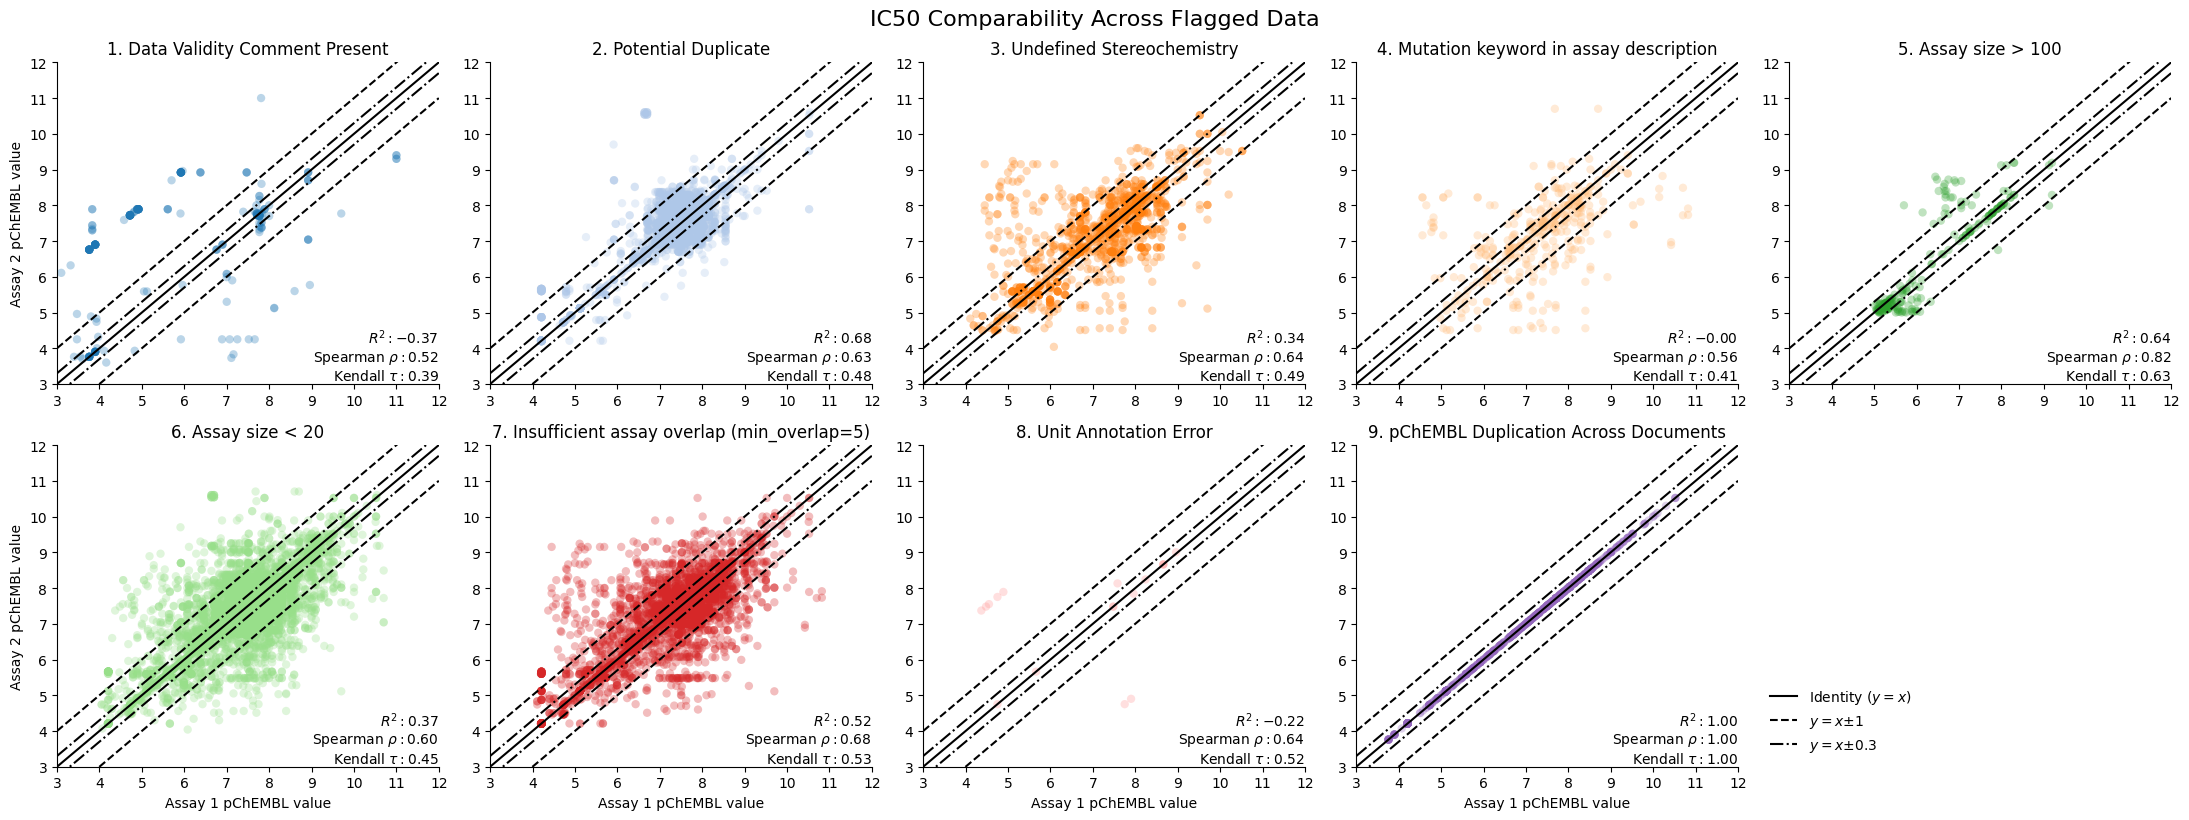

In [11]:
fig, axs = plot_multi_panel_comparability(
    exploded_subset, all_comments, title="IC50 Comparability Across Flagged Data", figsize=(22, 8), ncols=5
)
fig.savefig("ic50_comparability_allflags.png", dpi=300, bbox_inches="tight", transparent=False)

2026-02-27 14:34:11.083 | INFO     | Capricho.analysis:_log_comparability_metrics:805 - COMPARABILITY: Unprocessed IC50 Data — 2,693 pairwise comparisons
  Within ±0.3 log units:      939 ( 34.9%)
  Within ±1.0 log units:    2,042 ( 75.8%)
  Outside ±1.0 log units:     651 ( 24.2%)
  Spearman rho: 0.609  |  Kendall tau: 0.454  |  R²: 0.257


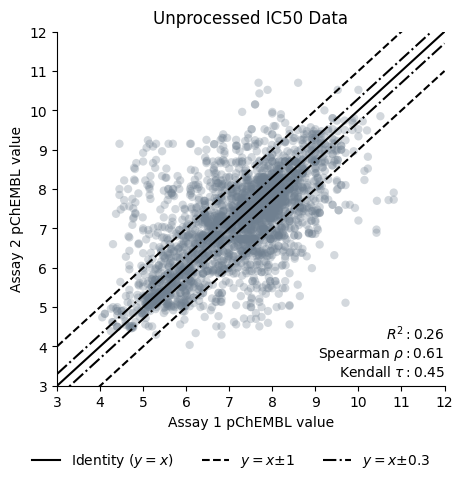

In [12]:
drop_flags_rm = [
    DroppingComment.DATA_VALIDITY_COMMENT.value,
    DroppingComment.POTENTIAL_DUPLICATE.value,
]

drop_flags_rm = "|".join(drop_flags_rm)

fig, ax = plot_subset(
    exploded_subset.query("(~dropping_comment.str.contains(@drop_flags_rm, regex=True))").query(
        "pchembl_value_x != pchembl_value_y"
    ),
    title="Unprocessed IC50 Data",
    figsize=(5, 4.6),
)

fig.savefig("ic50_unprocessed_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

2026-02-27 14:34:11.458 | INFO     | Capricho.analysis:_log_comparability_metrics:805 - COMPARABILITY: Cleaned IC50 Data — 556 pairwise comparisons
  Within ±0.3 log units:      248 ( 44.6%)
  Within ±1.0 log units:      462 ( 83.1%)
  Outside ±1.0 log units:      94 ( 16.9%)
  Spearman rho: 0.778  |  Kendall tau: 0.595  |  R²: 0.486


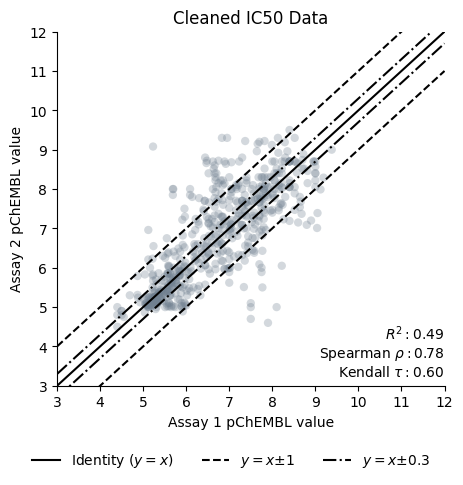

In [13]:
drop_flags_rm = [
    DroppingComment.DATA_VALIDITY_COMMENT.value,
    DroppingComment.POTENTIAL_DUPLICATE.value,
    DroppingComment.ASSAY_SIZE_TOO_SMALL.value,
    DroppingComment.MUTATION_KEYWORD.value,
    DroppingComment.UNDEFINED_STEREOCHEMISTRY.value,
    DroppingComment.UNIT_ANNOTATION_ERROR.value,
]
rm_process_obs = ProcessingComment.PCHEMBL_DUPLICATION_ACROSS_DOCUMENTS.value

drop_flags_rm = "|".join(drop_flags_rm)

subset_ki_clean = exploded_subset.query(
    "(~dropping_comment.str.contains(@drop_flags_rm, regex=True)) "
    "& ~processing_comment.str.contains(@rm_process_obs, regex=True)"
    "& pchembl_value_x != pchembl_value_y"
)
fig, ax = plot_subset(subset_ki_clean, title="Cleaned IC50 Data", figsize=(5, 4.6))
fig.savefig("ic50_clean_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

# Ki overlap

In [14]:
df_ki = pd.read_csv(ki_output, engine="pyarrow")
subset_ki = df_ki.query('processed_smiles.str.contains("|", regex=False)').assign(
    repeat=lambda x: range(len(x))
)
subset_ki.shape

(5201, 39)

In [15]:
all_comments = get_all_comments()
exploded_subset_ki = explode_assay_comparability(subset_ki)

2026-02-27 14:34:13.450 | INFO     | Capricho.analysis:_log_comparability_metrics:805 - COMPARABILITY: Data Validity Comment Present — 322 pairwise comparisons
  Within ±0.3 log units:      107 ( 33.2%)
  Within ±1.0 log units:      118 ( 36.6%)
  Outside ±1.0 log units:     204 ( 63.4%)
  Spearman rho: 0.174  |  Kendall tau: 0.146  |  R²: -0.795
2026-02-27 14:34:13.461 | INFO     | Capricho.analysis:_log_comparability_metrics:805 - COMPARABILITY: Potential Duplicate — 3,384 pairwise comparisons
  Within ±0.3 log units:    2,301 ( 68.0%)
  Within ±1.0 log units:    3,207 ( 94.8%)
  Outside ±1.0 log units:     177 (  5.2%)
  Spearman rho: 0.926  |  Kendall tau: 0.802  |  R²: 0.874
2026-02-27 14:34:13.468 | INFO     | Capricho.analysis:_log_comparability_metrics:805 - COMPARABILITY: Undefined Stereochemistry — 1,542 pairwise comparisons
  Within ±0.3 log units:      818 ( 53.0%)
  Within ±1.0 log units:    1,257 ( 81.5%)
  Outside ±1.0 log units:     285 ( 18.5%)
  Spearman rho: 0.650  |

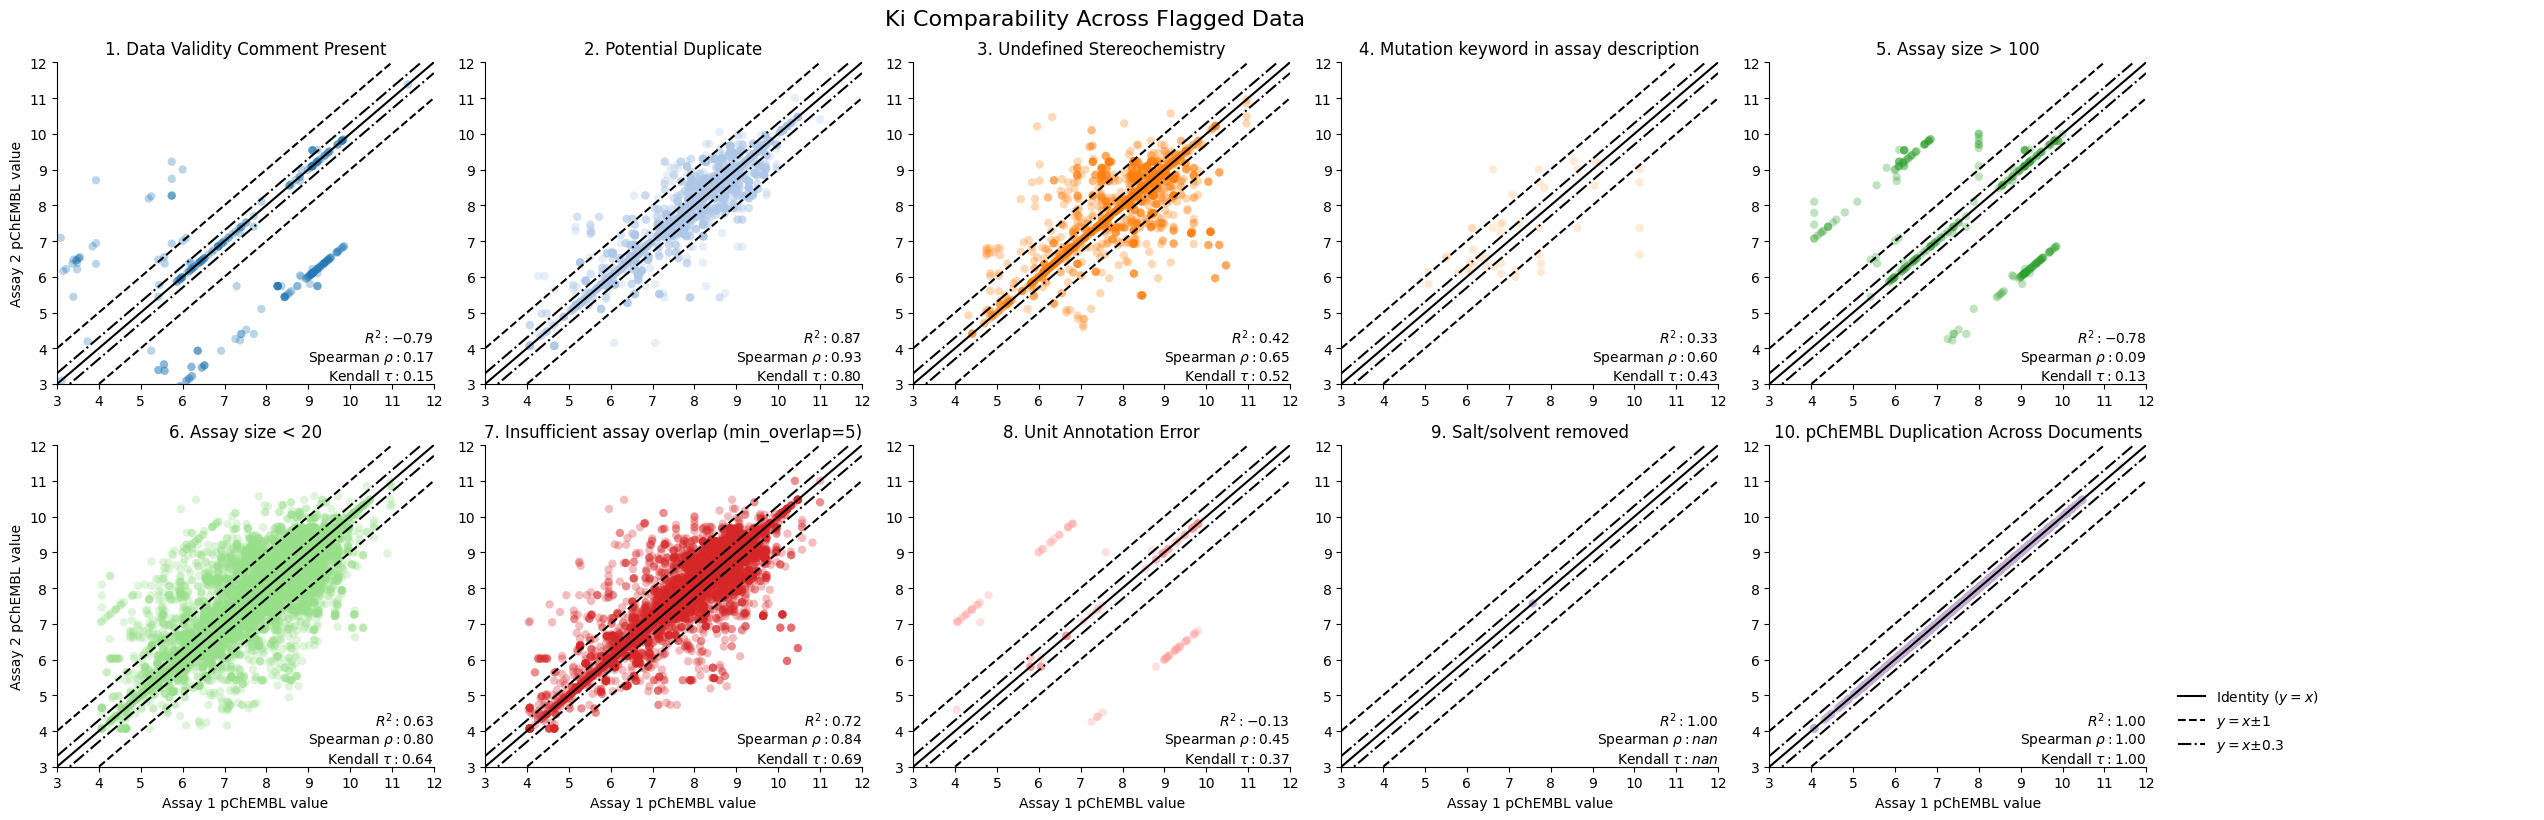

In [16]:
fig, axs = plot_multi_panel_comparability(
    exploded_subset_ki, all_comments, title="Ki Comparability Across Flagged Data", figsize=(22, 8), ncols=5
)
fig.savefig("ki_flagged_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

2026-02-27 14:34:15.279 | INFO     | Capricho.analysis:_log_comparability_metrics:805 - COMPARABILITY: Unprocessed Ki Data — 3,173 pairwise comparisons
  Within ±0.3 log units:    1,154 ( 36.4%)
  Within ±1.0 log units:    2,333 ( 73.5%)
  Outside ±1.0 log units:     840 ( 26.5%)
  Spearman rho: 0.669  |  Kendall tau: 0.499  |  R²: 0.377


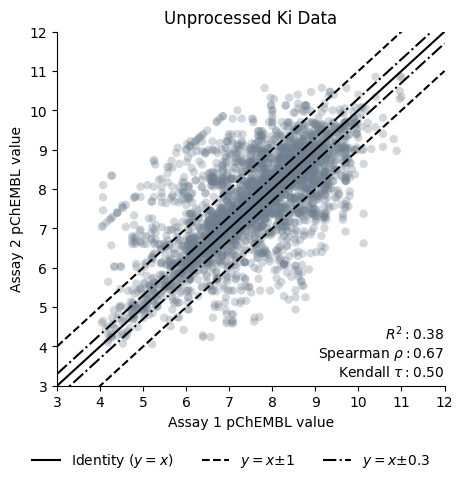

In [17]:
drop_flags_rm = [
    DroppingComment.DATA_VALIDITY_COMMENT.value,
    DroppingComment.POTENTIAL_DUPLICATE.value,
]

drop_flags_rm = "|".join(drop_flags_rm)

fig, ax = plot_subset(
    exploded_subset_ki.query("(~dropping_comment.str.contains(@drop_flags_rm, regex=True))").query(
        "pchembl_value_x != pchembl_value_y"
    ),
    title="Unprocessed Ki Data",
    figsize=(5, 4.6),
)

fig.savefig("ki_unprocessed_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

2026-02-27 14:34:15.511 | INFO     | Capricho.analysis:_log_comparability_metrics:805 - COMPARABILITY: Cleaned Ki Data — 383 pairwise comparisons
  Within ±0.3 log units:      220 ( 57.4%)
  Within ±1.0 log units:      348 ( 90.9%)
  Outside ±1.0 log units:      35 (  9.1%)
  Spearman rho: 0.854  |  Kendall tau: 0.717  |  R²: 0.777


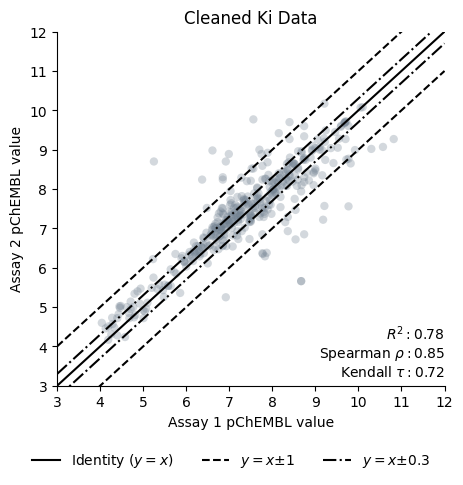

In [18]:
drop_flags_rm = [
    DroppingComment.DATA_VALIDITY_COMMENT.value,
    DroppingComment.POTENTIAL_DUPLICATE.value,
    DroppingComment.ASSAY_SIZE_TOO_LARGE.value,
    DroppingComment.ASSAY_SIZE_TOO_SMALL.value,
]
rm_process_obs = ProcessingComment.PCHEMBL_DUPLICATION_ACROSS_DOCUMENTS.value


drop_flags_rm = "|".join(drop_flags_rm)


subset_ki_clean = exploded_subset_ki.query(
    "(~dropping_comment.str.contains(@drop_flags_rm, regex=True)) "
    "& ~processing_comment.str.contains(@rm_process_obs, regex=True)"
    "& pchembl_value_x != pchembl_value_y"
).query("pchembl_value_x != pchembl_value_y")
fig, ax = plot_subset(subset_ki_clean, title="Cleaned Ki Data", figsize=(5, 4.6))

fig.savefig("ki_clean_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

In [19]:
potential_duplicates = subset_ki_clean = exploded_subset_ki.query(
    "(~dropping_comment.str.contains(@drop_flags_rm, regex=True)) "
    "& ~processing_comment.str.contains(@rm_process_obs, regex=True)"
).query("pchembl_value_x == pchembl_value_y")